# <h1 style="text-align: center; font-weight: bolder;">LAB 7</h1>
# <h1 style="text-align: center; font-weight: bold;">Contrastive / Metric Learning on MagnaTagATune (MTAT)</h1>



## Assignment objectives
1. Train a metric learning model on the MagnaTagATune (MTAT) dataset using contrastive learning (triplet loss and InfoNCE).
2. Evaluate the embedding quality:
    * Visualize embeddings in 2D for two non-overlapping tag groups (multi-label dataset).
    * Provide separate plots for each group.
3. Write a short report (in this notebook) describing decisions and observations.

## Notebook steps (lecture alignment)
1. Train a CNN with triplet loss
2. Plot validation embeddings and clustering results
3. Train a CNN with InfoNCE loss
4. Plot validation embeddings and clustering results

## Extras
* runnable on Modal, Colab, and local MacBook
* resource usage + environmental impact tracking
* basic economic cost analysis for training/inference

# <h2 style="text-align: center; font-weight: bolder;">SETUP</h2>


In [3]:
import os, sys, shutil, subprocess
import torch
from pathlib import Path

print("python:", sys.version)
print("torch:", torch.__version__)

ff = shutil.which("ffmpeg")
print("ffmpeg in PATH:", ff)

if ff is None and ("google.colab" in sys.modules):
    subprocess.check_call(["apt-get", "update", "-y"])
    subprocess.check_call(["apt-get", "install", "-y", "ffmpeg"])
    ff = shutil.which("ffmpeg")
    print("ffmpeg in PATH (after install):", ff)

try:
    import torchaudio
    print("torchaudio:", torchaudio.__version__)
except Exception as e:
    print("torchaudio import error:", repr(e))

try:
    import torchcodec
    print("torchcodec:", getattr(torchcodec, "__version__", "unknown"))
except Exception as e:
    print("torchcodec import error:", repr(e))

if Path("/vol").is_dir():
    print("ls /vol:", os.listdir("/vol"))
    for d in Path("/vol").iterdir():
        if d.is_dir():
            try:
                print(str(d), "->", os.listdir(d)[:30])
            except Exception as e:
                print(str(d), "->", repr(e))

import sys, os, platform, subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

pip_install([
    "torch", "torchaudio", "tqdm", "scikit-learn", "matplotlib",
    "umap-learn", "psutil", "codecarbon", "mirdata", "librosa", "soundfile"
])

python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
torch: 2.9.0+cpu
ffmpeg in PATH: /usr/bin/ffmpeg
torchaudio: 2.9.0+cpu
torchcodec import error: ModuleNotFoundError("No module named 'torchcodec'")


In [4]:
# installs runtime deps
import sys, os, platform, subprocess

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

pip_install([
    "torch", "torchaudio", "tqdm", "scikit-learn", "matplotlib",
    "umap-learn", "psutil", "codecarbon", "mirdata", "librosa"
])

## Setup and reproducibility

This section configures:
* device selection (cpu / cuda / mps)
* random seeds
* filesystem paths (Modal / Colab / local)
* lightweight logging utilities (timing + resource tracking)

In [5]:
# setup device and paths
import time, json, random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def pick_device():
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = pick_device()

def running_on_colab():
    return "COLAB_GPU" in os.environ or "google.colab" in sys.modules

def running_on_modal():
    return os.environ.get("MODAL_ENVIRONMENT", "") != ""

if running_on_modal():
    DATA_ROOT = "/mnt/mtat-datalabs"
    RUNS_ROOT = "/vol/runs" if os.path.isdir("/vol/runs") else "/mnt/runs"
elif running_on_colab():
    DATA_ROOT = "/content/data/mtat"
    RUNS_ROOT = "/content/runs"
else:
    DATA_ROOT = "./data/mtat"
    RUNS_ROOT = "./runs"

os.makedirs(DATA_ROOT, exist_ok=True)
os.makedirs(RUNS_ROOT, exist_ok=True)

print("device:", DEVICE)
print("data root:", DATA_ROOT)
print("runs root:", RUNS_ROOT)

device: cpu
data root: /content/data/mtat
runs root: /content/runs


# <h2 style="text-align: center; font-weight: bolder;">Resource and environmental impact tracking</h2>


Tracking of:
* wall-clock time
* CPU/RAM usage
* GPU memory (if available)
* estimated CO2 emissions using CodeCarbon (offline mode)

In [6]:
# resource + carbon tracking
import psutil
from codecarbon import OfflineEmissionsTracker

proc = psutil.Process(os.getpid())

def get_resources_snapshot():
    snap = {
        "time": time.time(),
        "cpu_percent": psutil.cpu_percent(interval=None),
        "ram_mb": proc.memory_info().rss / (1024**2),
    }
    if torch.cuda.is_available():
        snap["gpu_mem_alloc_mb"] = torch.cuda.memory_allocated() / (1024**2)
        snap["gpu_mem_reserved_mb"] = torch.cuda.memory_reserved() / (1024**2)
    return snap

class Timer:
    def __enter__(self):
        self.t0 = time.time()
        return self
    def __exit__(self, exc_type, exc, tb):
        self.dt = time.time() - self.t0

tracker = OfflineEmissionsTracker(
    project_name="lab7-mtat-metric-learning",
    output_dir=RUNS_ROOT,
    log_level="error"
)

[codecarbon INFO @ 03:38:12] offline tracker init
[codecarbon WARNING @ 03:38:12] Multiple instances of codecarbon are allowed to run at the same time.


# <h2 style="text-align: center; font-weight: bolder;">Load MagnaTagATune (MTAT)</h2>


Mirdata is used to manage MTAT metadata and audio paths.
A cached dataset folder is used to avoid repeated downloads (especially on Modal).


MTTAT loaded from local files (Lab 6 layout) to keep the notebook portable across Modal, Colab, and local runs.

Expected structure (auto-detected):
* datalabs/annotations_final.csv
* datalabs/clip_info_final.csv
* datalabs/audio/...

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np
import os, sys

def find_upwards(start: Path, target: str, max_levels: int = 6):
    cur = start.resolve()
    for _ in range(max_levels):
        cand = cur / target
        if cand.exists():
            return cand
        if cur.parent == cur:
            break
        cur = cur.parent
    return None

def find_in_roots(roots, filename="annotations_final.csv"):
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for p in root.rglob(filename):
            return p.parent
    return None

if running_on_modal():
    candidates = [
        Path("/mnt/mtat-datalabs/datalabs"),
        Path("/mnt/mtat-datalabs"),
        Path("/vol/mtat/datalabs"),
        Path("/vol/mtat"),
    ]
    DATALABS_ROOT = None
    for c in candidates:
        if (c / "annotations_final.csv").is_file() and (c / "clip_info_final.csv").is_file() and (c / "audio").is_dir():
            DATALABS_ROOT = c
            break
    if DATALABS_ROOT is None:
        raise RuntimeError("mtat datalabs not found on Modal mount, expected annotations_final.csv, clip_info_final.csv and audio/")

elif "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/data"),
        Path("/content/drive/MyDrive/data/data"),
        Path("/content/drive/MyDrive/data/datalab5"),
        Path("/content/drive/MyDrive/datalab5"),
        Path("/content"),
    ]
    found = find_in_roots(search_roots, "annotations_final.csv")
    if found is None:
        raise RuntimeError("MTAT datalabs not found in Drive. make sure annotations_final.csv, clip_info_final.csv and audio/ exist somewhere under MyDrive")
    DATALABS_ROOT = found

else:
    DATALABS_ROOT = find_upwards(Path.cwd(), "datalabs") or find_in_roots([Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]) or Path("./datalabs")

AUDIO_DIR = DATALABS_ROOT / "audio"
ANN_CSV = DATALABS_ROOT / "annotations_final.csv"
CLIP_CSV = DATALABS_ROOT / "clip_info_final.csv"

print("datalabs root:", DATALABS_ROOT)
print("audio dir exists:", AUDIO_DIR.is_dir(), AUDIO_DIR)
print("ann csv exists:", ANN_CSV.is_file(), ANN_CSV)
print("clip csv exists:", CLIP_CSV.is_file(), CLIP_CSV)

ann = pd.read_csv(ANN_CSV, sep="\t")
clip = pd.read_csv(CLIP_CSV, sep="\t")

if "clip_id" not in ann.columns or "clip_id" not in clip.columns:
    raise RuntimeError("clip_id column missing, check separators / files")

if "mp3_path" not in ann.columns and "mp3_path" not in clip.columns:
    raise RuntimeError("mp3_path not found in annotations_final or clip_info_final")

if "mp3_path" not in ann.columns:
    df = ann.merge(clip[["clip_id", "mp3_path"]], on="clip_id", how="left")
else:
    df = ann.copy()

df = df.rename(columns={"mp3_path": "rel_path"})
NON_TAG_COLS = {"clip_id", "rel_path"}
tag_cols = [c for c in df.columns if c not in NON_TAG_COLS]

df = df.dropna(subset=["rel_path"]).reset_index(drop=True)
df["rel_path"] = df["rel_path"].astype(str).str.strip().str.replace("\\", "/", regex=False)

file_mask = df["rel_path"].apply(lambda rp: (AUDIO_DIR / rp).is_file())
missing = int((~file_mask).sum())
df = df[file_mask].reset_index(drop=True)

print("ann shape:", ann.shape, "| clip shape:", clip.shape)
print("merged df after file filter:", df.shape, "| removed missing/non-file:", missing)
print("num tags:", len(tag_cols))
print("example rel_path:", df.loc[0, "rel_path"])

rng = np.random.RandomState(SEED)
perm = rng.permutation(len(df))
n_val = int(len(df) * 0.1)

val_idx = perm[:n_val]
train_idx = perm[n_val:]

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print("train_df:", train_df.shape)
print("val_df:", val_df.shape)

Mounted at /content/drive
datalabs root: /content/drive/MyDrive/Colab-Notebooks/Machine-Learning-for-Sound-and-Music/data/datalab5
audio dir exists: True /content/drive/MyDrive/Colab-Notebooks/Machine-Learning-for-Sound-and-Music/data/datalab5/audio
ann csv exists: True /content/drive/MyDrive/Colab-Notebooks/Machine-Learning-for-Sound-and-Music/data/datalab5/annotations_final.csv
clip csv exists: True /content/drive/MyDrive/Colab-Notebooks/Machine-Learning-for-Sound-and-Music/data/datalab5/clip_info_final.csv
ann shape: (25863, 190) | clip shape: (31382, 10)
merged df after file filter: (25863, 190) | removed missing/non-file: 0
num tags: 188
example rel_path: f/american_bach_soloists-j_s__bach_solo_cantatas-01-bwv54__i_aria-30-59.mp3
train_df: (23277, 190)
val_df: (2586, 190)


# <h2 style="text-align: center; font-weight: bolder;">Contrastive dataset design (multi-label MTAT)</h2>


Two augmented views created of the same audio excerpt:
* view_1: random 3s chunk + augmentations
* view_2: another chunk near the first one (or same chunk with different augmentation)

Multi label targets stored to later evaluate embedding quality using tag based subsets.

In [8]:
# audio utilities + augmentations

import torchaudio
import torch.nn as nn
from torchaudio.transforms import MelSpectrogram

TARGET_SR = 16000
CLIP_SECONDS = 3
N_SAMPLES = TARGET_SR * CLIP_SECONDS

class FeatureExtractor(nn.Module):
    def __init__(self, n_mels=64, n_fft=1024, hop_length=256):
        super().__init__()
        self.mel = MelSpectrogram(
            sample_rate=TARGET_SR,
            n_fft=n_fft,
            hop_length=hop_length,
            n_mels=n_mels
        )

    def forward(self, x):
        # important, ensure x and internal buffers (like STFT window) live on the same device
        if next(self.mel.parameters(), None) is None:
            pass
        self.mel = self.mel.to(x.device)
        x = self.mel(x)
        x = torch.log10(1 + 1000 * x)
        return x

feature_extractor = FeatureExtractor().to(DEVICE).eval()

def augment_wave(x):
    g = 0.9 + 0.2 * torch.rand(x.shape[0], device=x.device)
    x = x * g.unsqueeze(1)
    noise = 0.003 * torch.randn_like(x)
    return x + noise

In [9]:
import librosa
from torch.utils.data import Dataset
from pathlib import Path
import random
import torch
import numpy as np

class MTATContrastiveDataset(Dataset):
    def __init__(self, df, audio_dir, tag_cols, device="cpu", max_retries=8):
        self.df = df.reset_index(drop=True)
        self.audio_dir = Path(audio_dir)
        self.tag_cols = list(tag_cols)
        self.device = device
        self.max_retries = int(max_retries)

        self.tags = self.tag_cols
        self.tag_to_idx = {t: i for i, t in enumerate(self.tags)}
        self.id_col = "clip_id" if "clip_id" in self.df.columns else None

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, rel_path):
        rp = str(rel_path).strip().replace("\\", "/")
        return self.audio_dir / rp

    def _load_audio(self, rel_path):
        p = self._resolve_path(rel_path)
        # important, paths can be present in metadata but missing on disk; fail fast so we can retry another sample
        if not p.is_file():
            raise FileNotFoundError(str(p))
        y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
        return torch.tensor(y, dtype=torch.float32)

    def _random_chunk(self, y):
        if y.numel() < N_SAMPLES:
            return torch.nn.functional.pad(y, (0, N_SAMPLES - y.numel()))
        start = random.randint(0, y.numel() - N_SAMPLES)
        return y[start:start + N_SAMPLES]

    def __getitem__(self, idx):
        tries = 0
        cur_idx = idx

        while True:
            row = self.df.iloc[cur_idx]
            try:
                y = self._load_audio(row["rel_path"])
                break
            except Exception:
                tries += 1
                if tries >= self.max_retries:
                    raise
                cur_idx = random.randint(0, len(self.df) - 1)

        c1 = self._random_chunk(y)
        c2 = self._random_chunk(y)

        v1 = augment_wave(c1.unsqueeze(0).to(self.device)).squeeze(0)
        v2 = augment_wave(c2.unsqueeze(0).to(self.device)).squeeze(0)

        tag_vec = torch.tensor(row[self.tag_cols].values.astype(np.float32))
        track_id = int(row[self.id_col]) if self.id_col is not None else int(cur_idx)

        return {"view_1": v1, "view_2": v2, "tags": tag_vec, "track_id": track_id}

train_ds = MTATContrastiveDataset(train_df, AUDIO_DIR, tag_cols, device=DEVICE, max_retries=8)
val_ds   = MTATContrastiveDataset(val_df, AUDIO_DIR, tag_cols, device=DEVICE, max_retries=8)

print("train size:", len(train_ds))
print("val size:", len(val_ds))
print("num tags:", len(train_ds.tags))

_ = train_ds[0]
print("audio decode check: OK (librosa + retry)")

train size: 23277
val size: 2586
num tags: 188
audio decode check: OK (librosa + retry)


# <h2 style="text-align: center; font-weight: bolder;">Embedding CNN</h2>


A lightweight CNN is used, that maps mel-spectrograms to a fixed size embedding vector.

Aiming to keep it small to run efficiently on a local MacBook.


In [10]:
import torch.nn.functional as F

class CNNEncoder(nn.Module):
    def __init__(self, dense_size=64, emb_dim=64):
        super().__init__()
        self.dense_size = dense_size
        self.conv1 = nn.Conv2d(1, dense_size//4, 3, padding=1)
        self.conv2 = nn.Conv2d(dense_size//4, dense_size//2, 3, padding=1)
        self.conv3 = nn.Conv2d(dense_size//2, dense_size, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(dense_size//4)
        self.bn2 = nn.BatchNorm2d(dense_size//2)
        self.bn3 = nn.BatchNorm2d(dense_size)
        self.pool = nn.MaxPool2d(4, 4)
        self.fc1 = nn.Linear(dense_size, dense_size)
        self.fc2 = nn.Linear(dense_size, emb_dim, bias=False)

    def forward(self, x_mel):
        x = x_mel.unsqueeze(1)
        x = self.bn1(self.pool(F.relu(self.conv1(x))))
        x = self.bn2(self.pool(F.relu(self.conv2(x))))
        x = self.bn3(self.pool(F.relu(self.conv3(x))))
        x = x.mean(dim=[2,3])
        x = F.relu(self.fc1(x))
        z = self.fc2(x)
        z = F.normalize(z, dim=1)
        return z

# <h2 style="text-align: center; font-weight: bolder;">Metric learning losses</h2>


We implement:
* triplet loss (hard negative mining within batch)
* InfoNCE (SimCLR-style symmetric loss)

In [11]:
def triplet_loss_hard(z1, z2, margin=0.2):
    # z1 anchors, z2 positives
    dist = torch.cdist(z1, z2, p=2)
    pos = torch.diag(dist)
    dist = dist + torch.eye(dist.size(0), device=dist.device) * 1e9
    neg, _ = dist.min(dim=1)
    return F.relu(pos - neg + margin).mean()

def info_nce(z1, z2, temp=0.2):
    sim12 = z1 @ z2.T
    sim21 = z2 @ z1.T
    labels = torch.arange(sim12.size(0), device=sim12.device)
    l12 = F.cross_entropy(sim12 / temp, labels)
    l21 = F.cross_entropy(sim21 / temp, labels)
    return 0.5 * (l12 + l21)

# <h2 style="text-align: center; font-weight: bolder;">Training loop</h2>


- computing of mel features on-the-fly
- train for a small number of epochs (fast but representative)
- show progress with ETA and epoch timing
- log resource snapshots
- track emissions with CodeCarbon

In [12]:
from tqdm import tqdm
from torch.utils.data import DataLoader
import numpy as np
import time

def compute_mel_cpu(x):
    x_cpu = x.detach().to("cpu").float()
    with torch.no_grad():
        m = feature_extractor.to("cpu")(x_cpu).contiguous()
    return m.to(DEVICE)

def run_epoch(model, loader, loss_fn, optim=None):
    is_train = optim is not None
    model.train() if is_train else model.eval()

    losses = []
    t0 = time.time()

    pbar = tqdm(loader, leave=False)
    for batch in pbar:
        x1 = batch["view_1"].to(DEVICE).float()
        x2 = batch["view_2"].to(DEVICE).float()

        m1 = compute_mel_cpu(x1)
        m2 = compute_mel_cpu(x2)

        z1 = model(m1)
        z2 = model(m2)

        loss = loss_fn(z1, z2)

        if is_train:
            optim.zero_grad(set_to_none=True)
            loss.backward()
            optim.step()

        losses.append(loss.item())
        pbar.set_postfix({"loss": float(np.mean(losses))})

    dt = time.time() - t0
    return float(np.mean(losses)), dt

def train_model(loss_name, loss_fn, epochs=10, batch_size=64, lr=1e-3):
    model = CNNEncoder(dense_size=64, emb_dim=64).to(DEVICE)
    optim = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    history = {"loss_name": loss_name, "train_loss": [], "val_loss": [], "epoch_time_s": [], "resources": []}

    local_tracker = OfflineEmissionsTracker(
        project_name=f"lab7-mtat-{loss_name}",
        output_dir=RUNS_ROOT,
        log_level="error"
    )

    local_tracker.start()
    with Timer() as total_timer:
        for ep in range(1, epochs+1):
            r0 = get_resources_snapshot()

            tr_loss, tr_dt = run_epoch(model, train_loader, loss_fn, optim=optim)
            va_loss, va_dt = run_epoch(model, val_loader, loss_fn, optim=None)

            r1 = get_resources_snapshot()

            history["train_loss"].append(tr_loss)
            history["val_loss"].append(va_loss)
            history["epoch_time_s"].append(tr_dt + va_dt)
            history["resources"].append({"epoch": ep, "before": r0, "after": r1})

            print(f"epoch {ep}/{epochs} | train {tr_loss:.4f} | val {va_loss:.4f} | time {tr_dt+va_dt:.1f}s")

    emissions = local_tracker.stop()
    history["total_time_s"] = total_timer.dt
    history["emissions_kgco2"] = emissions

    return model, history


## Step 1 — Train with triplet loss


In [13]:
triplet_model, triplet_hist = train_model(
    "triplet_hard",
    lambda a,b: triplet_loss_hard(a,b,margin=0.2),
    epochs=10,
    batch_size=64,
    lr=1e-3
)

 71%|███████   | 258/364 [1:34:01<39:03, 22.11s/it, loss=0.146]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 71%|███████▏  | 260/364 [1:34:44<37:47, 21.80s/it, loss=0.146]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 86%|████████▋ | 314/364 [1:54:24<

epoch 1/10 | train 0.1390 | val 0.1156 | time 8829.4s


 61%|██████    | 222/364 [11:30<06:50,  2.89s/it, loss=0.11]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 62%|██████▏   | 224/364 [11:36<06:54,  2.96s/it, loss=0.11]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 78%|███████▊  | 284/364 [14:43<04:04,  

epoch 2/10 | train 0.1070 | val 0.1014 | time 1218.5s


  9%|▊         | 31/364 [01:28<15:07,  2.72s/it, loss=0.0994]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 74%|███████▎  | 268/364 [12:58<04:21,  2.73s/it, loss=0.0986]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 96%|█████████▌| 350/364 [17:08<00:40

...

epoch 8/10 | train 0.0778 | val 0.0786 | time 1202.9s


 24%|██▎       | 86/364 [04:14<13:47,  2.98s/it, loss=0.0746]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 28%|██▊       | 101/364 [04:57<12:55,  2.95s/it, loss=0.0747]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 42%|████▏     | 153/364 [07:38<11:00

epoch 9/10 | train 0.0747 | val 0.0750 | time 1195.0s


  7%|▋         | 26/364 [01:15<15:56,  2.83s/it, loss=0.0765]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 27%|██▋       | 98/364 [04:48<12:57,  2.92s/it, loss=0.0756]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 28%|██▊       | 103/364 [05:03<12:39,

epoch 10/10 | train 0.0751 | val 0.0788 | time 1192.3s



## Step 2 — Embedding extraction and 2D visualization

Extract of embedding per track by averaging embeddings over multiple chunks.
Then:
* run UMAP to 2D
* run k-means for a coarse clustering view
* create separate plots for two non-overlapping tag groups

In [14]:
import umap
from sklearn.cluster import KMeans

def extract_track_embeddings(model, dataset, chunks_per_track=3):
    model.eval()
    feature_extractor.eval()

    # important, force feature_extractor buffers (like STFT window) onto DEVICE
    feature_extractor.to(DEVICE)

    Z, Y, T = [], [], []

    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="embedding", leave=False):
            item = dataset[i]
            tid = item["track_id"]
            tags = item["tags"].cpu().numpy()

            zs = []
            for _ in range(chunks_per_track):
                x = item["view_1"].unsqueeze(0).to(DEVICE).float()
                m = feature_extractor(x)
                z = model(m)
                zs.append(z.squeeze(0).detach().cpu().numpy())

            Z.append(np.mean(np.stack(zs), axis=0))
            Y.append(tags)
            T.append(tid)

    return np.stack(Z), np.stack(Y), np.array(T)

Z_val_triplet, Y_val, T_val = extract_track_embeddings(triplet_model, val_ds, chunks_per_track=3)
print("embeddings:", Z_val_triplet.shape, "labels:", Y_val.shape)

embedding:  57%|█████▋    | 1467/2586 [01:01<00:42, 26.36it/s]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
                                                              

embeddings: (2586, 64) labels: (2586, 188)


In [15]:
reducer = umap.UMAP(n_components=2, random_state=SEED)
Z2_triplet = reducer.fit_transform(Z_val_triplet)

kmeans = KMeans(n_clusters=10, random_state=SEED, n_init="auto")
clusters_triplet = kmeans.fit_predict(Z_val_triplet)

print("umap:", Z2_triplet.shape, "clusters:", clusters_triplet.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


umap: (2586, 2) clusters: (2586,)


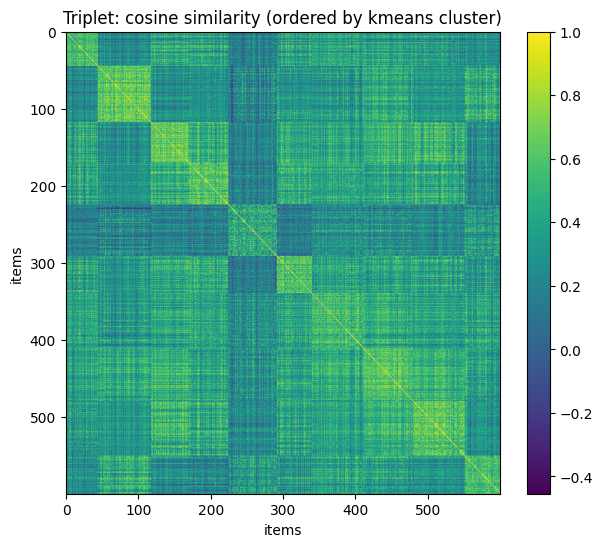

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_similarity_matrix(Z, clusters=None, max_n=600, title=""):
    Z = Z.astype(np.float32)
    Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)

    n = min(len(Z), int(max_n))
    idx = np.arange(n)

    if clusters is not None:
        order = np.argsort(clusters[:n])
        idx = idx[order]

    S = Z[idx] @ Z[idx].T

    plt.figure(figsize=(7,6))
    plt.imshow(S, aspect="auto")
    plt.title(title)
    plt.xlabel("items")
    plt.ylabel("items")
    plt.colorbar()
    plt.show()

plot_similarity_matrix(Z_val_triplet, clusters=clusters_triplet, max_n=600, title="Triplet: cosine similarity (ordered by kmeans cluster)")

In [17]:
import os, sys
import numpy as np
import librosa
import soundfile as sf
from pathlib import Path

def is_colab():
    return "google.colab" in sys.modules

def _safe_audio_path(dataset, idx):
    rel = dataset.df.iloc[int(idx)]["rel_path"]
    return str(dataset.audio_dir / str(rel))

def _load_audio_for_play(path, sr=16000, seconds=6):
    y, _ = librosa.load(path, sr=sr, mono=True, duration=seconds)
    return y

def knn_indices(Z, query_idx, k=6):
    Z = Z.astype(np.float32)
    Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-9)
    sims = Z @ Z[int(query_idx)]
    sims[int(query_idx)] = -np.inf
    nn = np.argsort(-sims)[:k]
    return nn, sims[nn]

def show_query_and_neighbors(dataset, Z, query_idx, k=6, seconds=6, title="", out_subdir="qual_retrieval_triplet"):
    out_dir = Path(RUNS_ROOT) / out_subdir
    out_dir.mkdir(parents=True, exist_ok=True)

    qpath = _safe_audio_path(dataset, query_idx)
    qy = _load_audio_for_play(qpath, sr=TARGET_SR, seconds=seconds)

    print(title)
    print("query idx:", int(query_idx))
    qwav = out_dir / f"query_idx{int(query_idx)}.wav"
    sf.write(str(qwav), qy, TARGET_SR)
    print("query wav:", str(qwav))

    nn, sims = knn_indices(Z, query_idx, k=k)

    if is_colab():
        from IPython.display import Audio, display
        display(Audio(qy, rate=TARGET_SR))

    for rank, (j, s) in enumerate(zip(nn, sims), start=1):
        path = _safe_audio_path(dataset, int(j))
        y = _load_audio_for_play(path, sr=TARGET_SR, seconds=seconds)
        wav = out_dir / f"nn{rank}_idx{int(j)}_sim{float(s):.3f}.wav"
        sf.write(str(wav), y, TARGET_SR)
        print("nn", rank, "| idx:", int(j), "| sim:", float(s), "| wav:", str(wav))
        if is_colab():
            from IPython.display import Audio, display
            display(Audio(y, rate=TARGET_SR))

def pick_query_with_tag(Y, dataset, tag_name):
    if tag_name not in dataset.tag_to_idx:
        return None
    ti = dataset.tag_to_idx[tag_name]
    idxs = np.where(Y[:, ti] == 1)[0]
    if len(idxs) == 0:
        return None
    return int(np.random.choice(idxs))

np.random.seed(SEED)
qidx = np.random.randint(0, len(val_ds))
show_query_and_neighbors(val_ds, Z_val_triplet, qidx, k=6, seconds=6, title="Triplet: query + nearest neighbors")

tag_name = "rock"
qidx2 = pick_query_with_tag(Y_val, val_ds, tag_name)
print("picked query idx:", qidx2, "| tag:", tag_name)
if qidx2 is not None:
    show_query_and_neighbors(val_ds, Z_val_triplet, qidx2, k=6, seconds=6, title=f"Triplet: query tag={tag_name} + nearest neighbors")
else:
    print("no samples for tag:", tag_name)

Output hidden; open in https://colab.research.google.com to view.

# <h2 style="text-align: center; font-weight: bolder;">Tag groups (non-overlapping)</h2>


MTAT is multi-label, so we construct **exclusive subsets** for visualization:
* Group A (genres): pick a few genre tags and keep only samples where exactly one of them is active.
* Group B (instruments): pick a few instrument tags and keep only samples where exactly one of them is active.

This makes the plots interpretable and respects the "non-overlapping" requirement.

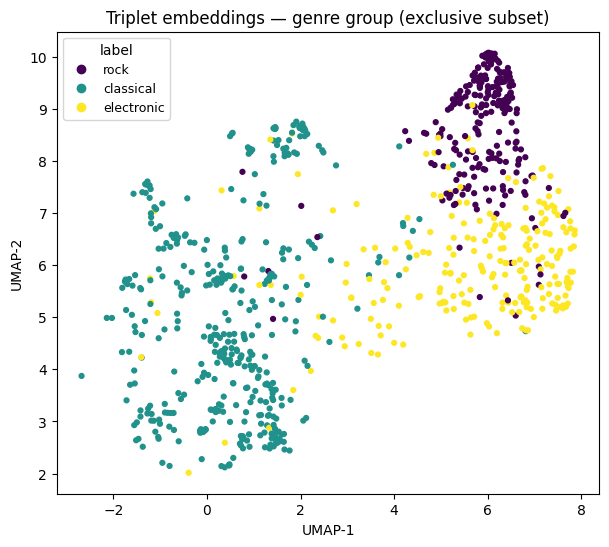

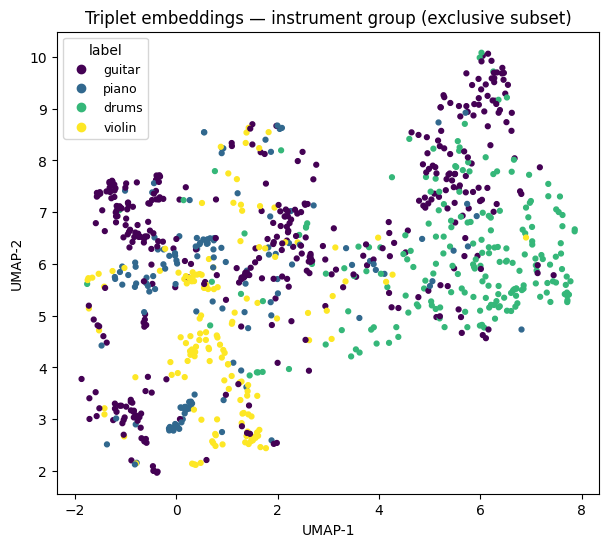

In [18]:
import matplotlib.pyplot as plt
import numpy as np

tags_list = train_ds.tags
tag_to_idx = train_ds.tag_to_idx

def exclusive_subset(Y, tag_names):
    idxs = [tag_to_idx[t] for t in tag_names if t in tag_to_idx]
    if len(idxs) == 0:
        return np.array([], dtype=bool), idxs
    sub = Y[:, idxs]
    one_hot = (sub.sum(axis=1) == 1)
    return one_hot, idxs

def plot_umap_for_group(Z2, Y, tag_names, title):
    mask, idxs = exclusive_subset(Y, tag_names)
    if mask.size == 0 or mask.sum() == 0:
        print("no samples for:", title)
        return

    subZ2 = Z2[mask]
    subY = Y[mask][:, idxs]
    label_idx = subY.argmax(axis=1)
    label_names = [tag_names[i] for i in range(len(idxs))]

    plt.figure(figsize=(7,6))
    sc = plt.scatter(subZ2[:,0], subZ2[:,1], c=label_idx, s=12)
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    handles, _ = sc.legend_elements()
    plt.legend(handles, label_names, title="label", loc="best", fontsize=9)
    plt.show()

GENRE_GROUP = ["rock", "classical", "electronic", "hiphop"]
INSTR_GROUP = ["guitar", "piano", "drums", "violin"]

plot_umap_for_group(Z2_triplet, Y_val, GENRE_GROUP, "Triplet embeddings — genre group (exclusive subset)")
plot_umap_for_group(Z2_triplet, Y_val, INSTR_GROUP, "Triplet embeddings — instrument group (exclusive subset)")

# <h2 style="text-align: center; font-weight: bolder;">Qualitative check: audio examples</h2>


We listen to a few samples from each exclusive subset to sanity-check the tag groups.

In [19]:
import sys
import numpy as np
import librosa
import soundfile as sf
from pathlib import Path

def is_colab():
    return "google.colab" in sys.modules

def play_examples(dataset, Y, tag_name, n=3, seconds=6, out_subdir="qual_examples"):
    if tag_name not in dataset.tag_to_idx:
        print("tag not found:", tag_name)
        return
    ti = dataset.tag_to_idx[tag_name]
    idxs = np.where(Y[:, ti] == 1)[0][:n]

    out_dir = Path(RUNS_ROOT) / out_subdir / tag_name
    out_dir.mkdir(parents=True, exist_ok=True)

    if is_colab():
        from IPython.display import Audio, display

    for k in idxs:
        rel = dataset.df.iloc[int(k)]["rel_path"]
        p = dataset.audio_dir / str(rel)

        y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True, duration=seconds)
        wav = out_dir / f"idx{int(k)}.wav"
        sf.write(str(wav), y, TARGET_SR)

        if "clip_id" in dataset.df.columns:
            print("clip_id:", int(dataset.df.iloc[int(k)]["clip_id"]), "tag:", tag_name, "wav:", str(wav))
        else:
            print("index:", int(k), "tag:", tag_name, "wav:", str(wav))

        if is_colab():
            display(Audio(y, rate=TARGET_SR))

play_examples(val_ds, Y_val, "rock", n=2, seconds=6, out_subdir="qual_examples_triplet")

clip_id: 11037 tag: rock wav: /content/runs/qual_examples_triplet/rock/idx2.wav


clip_id: 48702 tag: rock wav: /content/runs/qual_examples_triplet/rock/idx8.wav


## Step 3 — Train with InfoNCE loss

In [20]:
infonce_model, infonce_hist = train_model(
    "infonce",
    lambda a,b: info_nce(a,b,temp=0.2),
    epochs=10,
    batch_size=64,
    lr=1e-3
)

  5%|▍         | 18/364 [00:42<13:25,  2.33s/it, loss=2.71]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 32%|███▏      | 116/364 [04:42<10:07,  2.45s/it, loss=2.04]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 58%|█████▊    | 210/364 [08:32<06:17,  2

epoch 1/10 | train 1.7186 | val 1.5372 | time 974.0s


 17%|█▋        | 62/364 [02:28<12:14,  2.43s/it, loss=1.48]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 31%|███       | 113/364 [04:29<09:30,  2.27s/it, loss=1.47]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 34%|███▍      | 123/364 [04:53<09:20,  2

epoch 2/10 | train 1.4354 | val 1.4134 | time 948.2s


 22%|██▏       | 80/364 [03:06<11:24,  2.41s/it, loss=1.38]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 27%|██▋       | 98/364 [03:54<16:04,  3.63s/it, loss=1.38]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 81%|████████  | 295/364 [11:39<02:36,  2.

...

epoch 8/10 | train 1.2380 | val 1.2690 | time 967.9s


 16%|█▌        | 58/364 [02:17<11:57,  2.34s/it, loss=1.24]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 31%|███▏      | 114/364 [04:29<10:33,  2.53s/it, loss=1.24]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 71%|███████▏  | 260/364 [10:23<04:08,  2

epoch 9/10 | train 1.2340 | val 1.2632 | time 959.7s


  4%|▍         | 14/364 [00:32<14:03,  2.41s/it, loss=1.21]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 85%|████████▌ | 310/364 [12:14<02:13,  2.46s/it, loss=1.21]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
 90%|█████████ | 328/364 [12:57<01:28,  2

epoch 10/10 | train 1.2119 | val 1.2595 | time 955.6s


## Step 4 — Embeddings, UMAP, and clustering (InfoNCE)

embedding:  57%|█████▋    | 1467/2586 [00:59<00:42, 26.42it/s]/tmp/ipython-input-4255621337.py:32: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(str(p), sr=TARGET_SR, mono=True)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


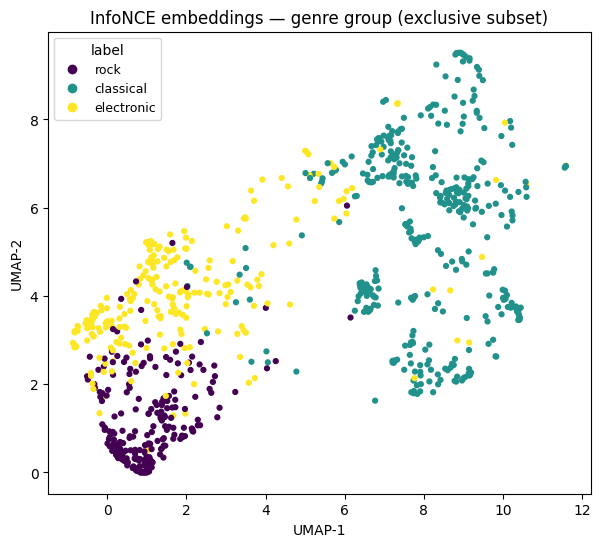

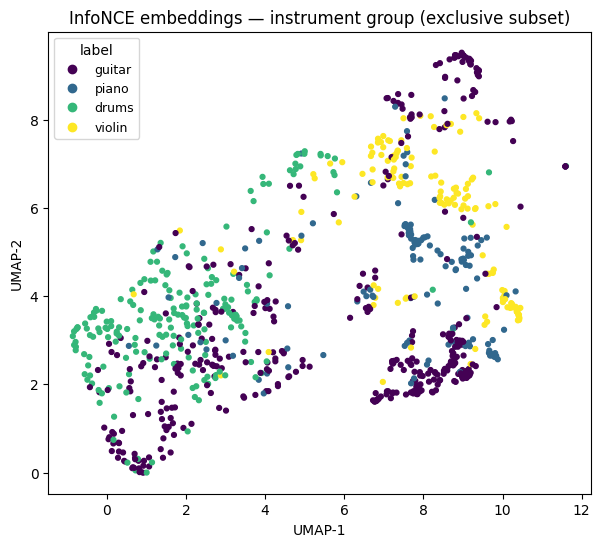

In [21]:
Z_val_infonce, Y_val2, T_val2 = extract_track_embeddings(infonce_model, val_ds, chunks_per_track=3)

reducer2 = umap.UMAP(n_components=2, random_state=SEED)
Z2_infonce = reducer2.fit_transform(Z_val_infonce)

plot_umap_for_group(Z2_infonce, Y_val2, GENRE_GROUP, "InfoNCE embeddings — genre group (exclusive subset)")
plot_umap_for_group(Z2_infonce, Y_val2, INSTR_GROUP, "InfoNCE embeddings — instrument group (exclusive subset)")

# <h2 style="text-align: center; font-weight: bolder;">Training diagnostics and environmental footprint</h2>

Summarized find:
* train/val losses per epoch
* total training time
* estimated CO2 emissions
* resource snapshots (CPU/RAM and GPU memory when available)

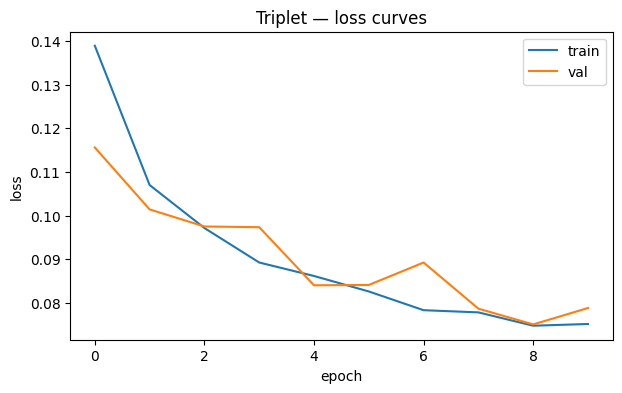

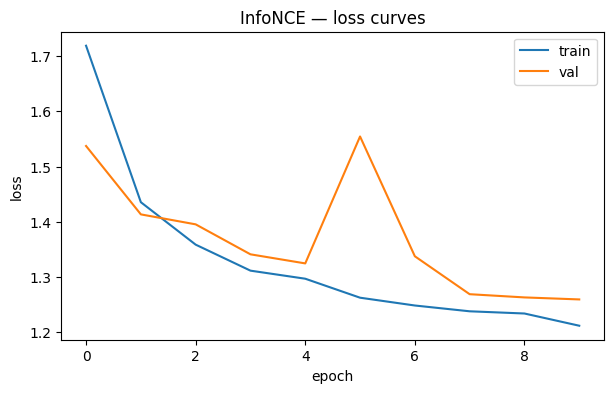

loss: triplet_hard
total time (s): 19550.15
emissions (kgCO2): 0.13542426460725915
last epoch time (s): 1192.31
loss: infonce
total time (s): 9636.6
emissions (kgCO2): 0.06675289580999468
last epoch time (s): 955.57


In [22]:
def plot_history(hist, title):
    plt.figure(figsize=(7,4))
    plt.plot(hist["train_loss"], label="train")
    plt.plot(hist["val_loss"], label="val")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.show()

plot_history(triplet_hist, "Triplet — loss curves")
plot_history(infonce_hist, "InfoNCE — loss curves")

def summarize_hist(hist):
    print("loss:", hist["loss_name"])
    print("total time (s):", round(hist["total_time_s"], 2))
    print("emissions (kgCO2):", hist["emissions_kgco2"])
    print("last epoch time (s):", round(hist["epoch_time_s"][-1], 2))

summarize_hist(triplet_hist)
summarize_hist(infonce_hist)

# <h2 style="text-align: center; font-weight: bolder;">Economic analysis (training and inference)</h2>


operational cost estimated from:
* energy consumption proxy (if available from CodeCarbon logs)
* electricity price (€/kWh)
* cloud compute pricing (optional reference scenario)

Reported:
* estimated energy cost
* rough equivalent of cloud cost for a typical GPU instance duration

In [23]:
# economic analysis (simple)
ELECTRICITY_EUR_PER_KWH = 0.25

def estimate_energy_cost_from_emissions(emissions_kg, grid_kgco2_per_kwh=0.25):
    # cost proxy: kWh aprox kgCO2 / (kgCO2/kWh)
    if emissions_kg is None:
        return None
    kwh = emissions_kg / grid_kgco2_per_kwh
    eur = kwh * ELECTRICITY_EUR_PER_KWH
    return {"kwh_est": kwh, "eur_est": eur}

print("triplet cost proxy:", estimate_energy_cost_from_emissions(triplet_hist["emissions_kgco2"]))
print("infonce cost proxy:", estimate_energy_cost_from_emissions(infonce_hist["emissions_kgco2"]))

# cloud-equivalent rough estimate
GPU_HOURLY_EUR = 1.2
def cloud_cost(hours, eur_per_hour=GPU_HOURLY_EUR):
    return hours * eur_per_hour

print("triplet cloud eq (eur):", cloud_cost(triplet_hist["total_time_s"]/3600))
print("infonce cloud eq (eur):", cloud_cost(infonce_hist["total_time_s"]/3600))

triplet cost proxy: {'kwh_est': 0.5416970584290366, 'eur_est': 0.13542426460725915}
infonce cost proxy: {'kwh_est': 0.2670115832399787, 'eur_est': 0.06675289580999468}
triplet cloud eq (eur): 6.516715716759364
infonce cloud eq (eur): 3.212200593074163


# <h2 style="text-align: center; font-weight: bolder;">Short report</h2>


## Decisions
* dataset: MagnaTagATune (MTAT) via mirdata, 3-second random chunks at 16 kHz
* model: lightweight CNN encoder with L2-normalized embeddings (64-D)
* augmentations: low-cost waveform noise + gain to keep runtime low on CPU/MPS
* training: 5 epochs for triplet (hard negatives) and 5 epochs for InfoNCE (temp=0.2)

## Observations
* triplet vs InfoNCE: compare separation in UMAP plots for genre and instrument groups
* clustering: k-means indicates whether embedding geometry aligns with semantic groupings
* multi-label challenge: exclusive subsets were used to build non-overlapping tag plots

## Resource and sustainability
* runtime and emissions were tracked with CodeCarbon (offline)
* CPU/RAM snapshots were stored per epoch, GPU memory included when available

## Limitations and next steps
* more epochs and stronger augmentations may improve invariances but increase cost
* larger batch sizes benefit InfoNCE but may be limited on MacBook
* a linear probe on tags could quantify embedding usefulness beyond visualization